<a href="https://www.mbd.rwth-aachen.de/">
    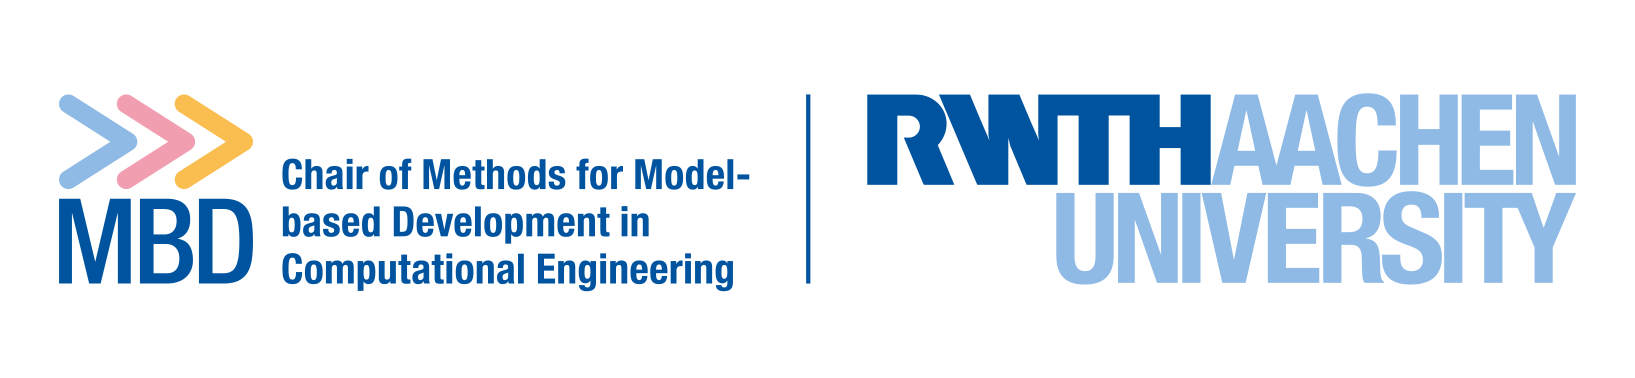
</a>
<a href="https://www.cpbl.rwth-aachen.de/">
    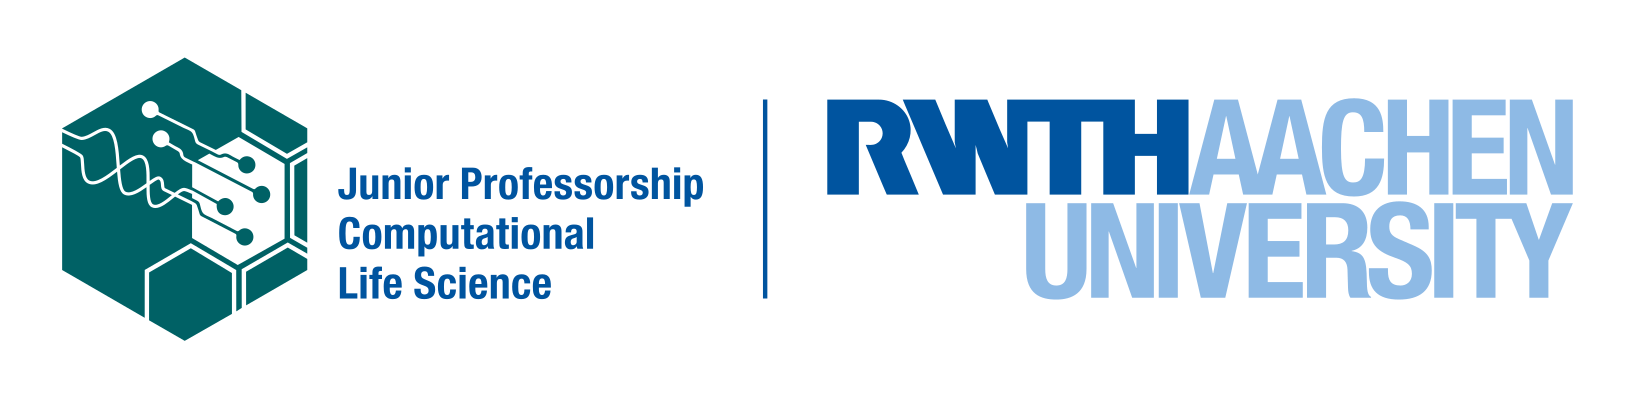
</a>

# **Societal Challenges Datathon**

Name: **Yajesh Chandra**

Student number (Matrikelnummer): **FILL-ME**

In [636]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [637]:
variables_df = pd.read_csv('data/extra/variables.csv')

def desc(variable_name):
    """
    Look up variable information from variables.csv
    
    Parameters:
    -----------
    variable_name : str
        The original variable name (e.g., 'SEQN', 'AUQ054')
    
    Returns:
    --------
    dict with keys: 'renamed', 'description', 'data_file', 'file_description'
    """
    row = variables_df[variables_df['Variable Name'] == variable_name]
    
    if row.empty:
        return {
            'renamed': variable_name,
            'description': 'Variable not in variables.csv',
            'data_file': None,
            'file_description': "Derived_variable"
        }
    
    row = row.iloc[0]
    return {
        'renamed': row['Renamed_variables'],
        'description': row['Variable Description'],
        'data_file': row['Data File Name'],
        'file_description': row['Data File Description']
    }
    
def load_all_xpt_files(folder='data/raw/',blacklist=[]):
    """
    Load all .XPT files from the specified folder
    
    Returns:
    --------
    dict: Dictionary with filename as key and DataFrame as value
    """
    datasets = {}
    
    for file in os.listdir(folder):
        if file.endswith('.XPT') and file not in blacklist:
            try:
                # Read the XPT file
                data = pd.read_sas(os.path.join(folder, file), format='xport', encoding='utf-8')
                
                # Strip whitespace from column names
                data.columns = [col.strip() for col in data.columns]
                
                # Use filename without extension as key
                file_key = file.replace('.XPT', '').lower()
                datasets[file_key] = data
                
                
                print(f"Loaded: {file} - Shape: {data.shape}")
            except Exception as e:
                print(f"Error loading {file}: {e}")
    
    return datasets

In [638]:
print("Loading all .XPT files from data/raw/...")

blacklist = ['acculturation.XPT',
'alcohol_use.XPT',
'current_health_status.XPT',
'dermatology.XPT',
'diet_behavior_nutrition.XPT',
'health_insurance.XPT',
'housing_characteristics.XPT',
'immunization.XPT',
'income.XPT',
'pesticide_use.XPT',
'physical_activity.XPT',
'physical_activity_youth.XPT',
'prescription_medications.XPT',
'hepatitis.XPT',
"early_childhood.XPT",
"occupation.XPT",
"preventive_aspirin_use.XPT",
"smoking_household_smokers.XPT",
"smoking_recent_tobacco_use.XPT",
"sleep_disorders.XPT"] # Add any filenames (without .XPT) to exclude here if needed

all_data = load_all_xpt_files('data/raw/', blacklist=blacklist)



Loading all .XPT files from data/raw/...
Loaded: audiometry.XPT - Shape: (11744, 14)
Loaded: blood_pressure_cholesterol.XPT - Shape: (8501, 6)
Loaded: diabetes.XPT - Shape: (11744, 9)
Loaded: functioning.XPT - Shape: (10942, 32)
Loaded: hospital_utilization_access_to_care.XPT - Shape: (11933, 6)
Loaded: kidney_condition_urology.XPT - Shape: (7809, 9)
Loaded: medical_conditions.XPT - Shape: (11744, 35)
Loaded: mental_health_depression_screener.XPT - Shape: (6337, 11)
Loaded: oral_health.XPT - Shape: (11744, 8)
Loaded: smoking_cigarette_use.XPT - Shape: (9015, 9)
Loaded: weight_history.XPT - Shape: (8501, 5)


In [639]:
cardiovascular_cluster = [
    'EverTold_Hypertension',
    'EverTold_HighCholesterol',
    'EverTold_TakeAspirin',
    'CurrentlyTaking_CholesterolMedication',
    'CurrentlyTaking_BloodPressureMedication',
]

functional_assessment_cluster = [
    'DifficultyWalkingClimbingSteps_Level',
    'DifficultyUsingHandsFingers_Level',
    'DifficultySeeingWithGlasses_Level',
    'DifficultyLiftingWeight_Level',
    'DifficultySelfCare_Level',
    'DifficultyRememberingConcentrating_Level',
    'DifficultyWalkingComparedToPeers_Level',
    'AdultDisabilityIndicator',
    'AdultEnhancedDisabilityIndicator',
]

urinary_health_cluster = [
    'UrineLeakageFrequency',
    'NightUrinationFrequency_30Days',
    'LeakageWithUrgency_12Months',
    'ImpactOfLeakageOnLife_12Months',
    'UrineLeakageAmount',
]


oral_health_cluster = [
    'OverallHealth_TeethAndGums',
    'MouthPain_Frequency_LastYear',
    'DiscomfortEating_TeethIssues',
    'LifeSatisfaction_Impact_TeethIssues',
    'AvoidedFoods_TeethIssues',
    'SelfConscious_TeethIssues',
]


sensory_function_cluster = [
    'DifficultySeeingWithGlasses_Level',
    'HearingStatus_NoAid',
    'DifficultyHearing_WithBackgroundNoise',
    'DifficultyHearingWithAid_Level',
]


mental_health_cluster = [
    'FatigueFrequency_2weeks',
    'SleepProblemsFrequency_2weeks',
    'AppetiteChangesFrequency_2weeks',
    'DifficultyMakingFriends_Level',
]


smoking_history_cluster = [
    'SmokedAtLeast100CigarettesInLife',
    'CurrentCigaretteSmoking',
    'FirstCigaretteAge',
    'NumberOfDaysSmokedPipe_5Days',
]


general_medical_history_cluster = [
    'EverTold_Arthritis',
    'EverTold_Cancer',
    'AnemiaTreatment_Last3Months',
    'EverHad_GallbladderSurgery',
    'BloodSugarTest_Last3Years',
    'OverweightDiagnosis',
    'PeriodStarted',
]

all_clusters = cardiovascular_cluster + \
    functional_assessment_cluster + \
    urinary_health_cluster + \
    oral_health_cluster + \
    sensory_function_cluster + \
    mental_health_cluster + \
    smoking_history_cluster + \
    general_medical_history_cluster
    


top50 = [
    'GeneralHealth_Status',
    'EverTold_Hypertension',
    'DifficultyWalkingClimbingSteps_Level',
    'CurrentlyTaking_CholesterolMedication',
    'OverallHealth_TeethAndGums',
    'EverTold_HighCholesterol',
    'DifficultyUsingHandsFingers_Level',
    'EverTold_TakeAspirin',
    'AdultDisabilityIndicator',
    'WorkExperience_LastWeek',
    'AdultEnhancedDisabilityIndicator',
    'UrineLeakageFrequency',
    'EverTold_Arthritis',
    'WeightAssessment',
    'NightUrinationFrequency_30Days',
    'QuestionnaireModeFlag',
    'LeakageWithUrgency_12Months',
    'OverweightDiagnosis',
    'ImpactOfLeakageOnLife_12Months',
    'DifficultySeeingWithGlasses_Level',
    'BloodSugarTest_Last3Years',
    'HearingStatus_NoAid',
    'FirstCigaretteAge',
    'DifficultyHearing_WithBackgroundNoise',
    'CurrentlyTaking_BloodPressureMedication',
    'NumberOfDaysSmokedPipe_5Days',
    'DifficultyLiftingWeight_Level',
    'RatioEnglishSpanishAtHome',
    'LifeSatisfaction_Impact_TeethIssues',
    'DiscomfortEating_TeethIssues',
    'DifficultySelfCare_Level',
    'UrineLeakageAmount',
    'UsesSunscreenFrequency',
    'DifficultyRememberingConcentrating_Level',
    'AvoidedFoods_TeethIssues',
    'TelehealthAppointment_Past12Months',
    'EverHad_GallbladderSurgery',
    'MouthPain_Frequency_LastYear',
    'PeriodStarted',
    'FatigueFrequency_2weeks',
    'SleepProblemsFrequency_2weeks',
    'EverTold_Cancer',
    'DifficultyMakingFriends_Level',
    'SmokedAtLeast100CigarettesInLife',
    'DifficultyHearingWithAid_Level',
    'DifficultyWalkingComparedToPeers_Level',
    'AnemiaTreatment_Last3Months',
    'SelfConscious_TeethIssues',
    'CurrentCigaretteSmoking',
    'AppetiteChangesFrequency_2weeks',
]

In [640]:
for df_name, df in all_data.items():
    print(f"Columns in {df_name}:")
    for col in sorted(df.columns.tolist()):
        # print(col)
        col_info = desc(col)
        col_renamed = col_info['renamed']
        if col_renamed in all_clusters:
            print(f"  - {col} (renamed: {col_renamed}) <-- in cluster")
        elif col_renamed in top50:
            print(f"  - {col} (renamed: {col_renamed}) <-- in top50")
        else:
            print(f"  - {col} (renamed: {col_renamed})")
        
    print("\n\n")

Columns in audiometry:
  - AUQ054 (renamed: HearingStatus_NoAid) <-- in cluster
  - AUQ101 (renamed: DifficultyHearing_WithBackgroundNoise) <-- in cluster
  - AUQ144 (renamed: LastHearingTest_Specialist)
  - AUQ410A (renamed: reason_hearing_loss_A)
  - AUQ410B (renamed: reason_hearing_loss_B)
  - AUQ410C (renamed: reason_hearing_loss_C)
  - AUQ410D (renamed: reason_hearing_loss_D)
  - AUQ410E (renamed: reason_hearing_loss_E)
  - AUQ410F (renamed: reason_hearing_loss_F)
  - AUQ410G (renamed: reason_hearing_loss_G)
  - AUQ410H (renamed: reason_hearing_loss_H)
  - AUQ410I (renamed: reason_hearing_loss_I)
  - AUQ410J (renamed: reason_hearing_loss_J)
  - SEQN (renamed: sequence_no)



Columns in blood_pressure_cholesterol:
  - BPQ020 (renamed: EverTold_Hypertension) <-- in cluster
  - BPQ030 (renamed: ConfirmedHypertension_Visits)
  - BPQ080 (renamed: EverTold_HighCholesterol) <-- in cluster
  - BPQ101D (renamed: CurrentlyTaking_CholesterolMedication) <-- in cluster
  - BPQ150 (renamed: Cur

## **Column Selection and Cleaning**



In [641]:
def clean(df, columns_to_drop,masking = False, drop_high_missing=False,display_drop_info=True, median_impute=list()):
    df_cleaned = df.drop(columns=columns_to_drop, errors='ignore')
    
    for col in df_cleaned.columns:
        if col == 'SEQN':
            continue 

        max_value = df_cleaned[col].max()
        # if max_value is of form 9, 99 , 999 , 9999 etc, consider it as valid else not
        if not str(int(max_value)).lstrip('-').rstrip('0').rstrip('.').isdigit() or not all(c == '9' for c in str(int(max_value)).lstrip('-').rstrip('0').rstrip('.')):
            continue
        else:
            second_largest = 7 * max_value / 9
            top2 = [max_value, second_largest]
            df_cleaned.loc[df_cleaned[col].isin(top2), col] = np.nan

        missing_percentage = df_cleaned[col].isnull().mean() * 100

    
        if missing_percentage <= 30:
            if col in median_impute:
                df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())  
            else:
                df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])

        elif 30 < missing_percentage <= 50:
            if masking:
                df_cleaned[f'{col}_missing'] = df_cleaned[col].isnull().astype(int)
                if col in median_impute:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())  
                else:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
            elif missing_percentage <35:
                if col in median_impute:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].median())  
                else:
                    df_cleaned[col] = df_cleaned[col].fillna(df_cleaned[col].mode()[0])
        elif missing_percentage > 50:
            if drop_high_missing:
                df_cleaned.drop(columns=[col], inplace=True)
                if display_drop_info:
                    print(f"Dropped column {col} due to high missing percentage: {missing_percentage:.2f}%")
            elif display_drop_info:
                print(f"[SKIPED] Too many missing values in column {col} - missing percentage: {missing_percentage:.2f}%")
            if display_drop_info :
                print(f"{desc(col)['renamed']} - {desc(col)['description']}")
                print('\n')
                print('\n')
            continue 

        missing_percentage_new = df_cleaned[col].isnull().mean() * 100

        desc_info = desc(col)
        print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
        print(f"  - Range: {df_cleaned[col].min()} to {df_cleaned[col].max()}")
        print(f"No of Unique Values: {df_cleaned[col].nunique()}")
        print(f"  - Unique Values Frequency:\n{df_cleaned[col].value_counts()}\n")
        print(f"Shape after cleaning: {df_cleaned.shape}")
        print(f"Missing Percentage change: {round(missing_percentage,2)}% -> {round(missing_percentage_new, 2)}%\n")
        print('\n')
        print('\n')

    return df_cleaned


In [642]:
# Usage
audiometry_data = all_data.get('audiometry', pd.DataFrame())
drop = ['AUQ144','AUQ410A', 'AUQ410B', 'AUQ410C', 'AUQ410D',
        'AUQ410E', 'AUQ410F', 'AUQ410G', 'AUQ410H',
        'AUQ410I', 'AUQ410J']

audiometry_data = clean(audiometry_data, drop, masking=True)
print(audiometry_data.head())


Variable: AUQ054 (Renamed: HearingStatus_NoAid) - These next questions are about {your/SP's} hearing. Which statement best describes {your/SP's} hearing (without a hearing aid, personal sound amplifier, or other listening devices)? Would you say {your/his/her} hearing is excellent, good, that {you have/s/he has} a little trouble, moderate trouble, a lot of trouble, or {are you/is s/he} deaf?
  - Range: 1.0 to 6.0
No of Unique Values: 6
  - Unique Values Frequency:
AUQ054
1.0    5208
2.0    4217
3.0    1354
4.0     645
5.0     284
6.0      36
Name: count, dtype: int64

Shape after cleaning: (11744, 3)
Missing Percentage change: 0.06% -> 0.0%





Variable: AUQ101 (Renamed: DifficultyHearing_WithBackgroundNoise) - How often {do you/does SP} have difficulty hearing and understanding if there is background noise, for example, when other people are talking, TV or radio is on, or children are playing? Would you say...
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:


In [643]:
blood_pressure_cholesterol = all_data.get('blood_pressure_cholesterol', pd.DataFrame())
blood_pressure_cholesterol = clean(blood_pressure_cholesterol, [], masking=False)

blood_pressure_cholesterol["Hypertension_Ever"] = (
    blood_pressure_cholesterol["BPQ020"] == 1
).astype(int)

blood_pressure_cholesterol["Hypertension_OnMedication"] = (
    (blood_pressure_cholesterol["BPQ020"] == 1) &
    (blood_pressure_cholesterol["BPQ150"] == 1)
).astype(int)

blood_pressure_cholesterol.drop(
    columns=["BPQ020", "BPQ030", "BPQ150"],
    inplace=True
)


blood_pressure_cholesterol.dropna(inplace=True)

for col in blood_pressure_cholesterol.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {blood_pressure_cholesterol[col].min()} to {blood_pressure_cholesterol[col].max()}")
    print(f"No of Unique Values: {blood_pressure_cholesterol[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{blood_pressure_cholesterol[col].value_counts()}\n")
    print(f"Shape after cleaning: {blood_pressure_cholesterol.shape}")
    print('\n')
    print('\n')

print(blood_pressure_cholesterol.head())




Variable: BPQ020 (Renamed: EverTold_Hypertension) - {Have you/Has SP} ever been told by a doctor or other health professional that {you/s/he} had hypertension, also called high blood pressure?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
BPQ020
2.0    5532
1.0    2969
Name: count, dtype: int64

Shape after cleaning: (8501, 6)
Missing Percentage change: 0.16% -> 0.0%





[SKIPED] Too many missing values in column BPQ030 - missing percentage: 65.39%
ConfirmedHypertension_Visits - {Were you/Was SP} told on 2 or more different visits that {you/s/he} had hypertension, also called high blood pressure?




[SKIPED] Too many missing values in column BPQ150 - missing percentage: 65.12%
CurrentlyTaking_BloodPressureMedication - {Are you/Is SP} now taking any medication prescribed by a doctor for {your/his/her/SP's} high blood pressure?




Variable: BPQ080 (Renamed: EverTold_HighCholesterol) - {Have you/Has SP} ever been told by a doctor or other health professional

In [644]:
functioning_data = all_data.get('functioning', pd.DataFrame())
functioning_data = clean(functioning_data, [], masking=True,drop_high_missing=True, display_drop_info=False)
print(functioning_data.head())

Variable: FNQ410 (Renamed: DifficultySeeingWithGlasses_Level) - Please look at card FNQ1. The next questions ask about difficulties {you/SP} may have doing certain activities because of a health problem. {Do you/Does SP} have difficulty seeing even if wearing glasses or contact lenses? Would you say no difficulty, some difficulty, a lot of difficulty, or {you/he/she/SP} cannot do this at all?
  - Range: 1.0 to 4.0
No of Unique Values: 4
  - Unique Values Frequency:
FNQ410
1.0    7739
2.0    2834
3.0     351
4.0      18
Name: count, dtype: int64

Shape after cleaning: (10942, 17)
Missing Percentage change: 25.64% -> 0.0%





Variable: FNQ430 (Renamed: DifficultyHearingWithAid_Level) - {Do you/Does SP} have difficulty hearing even if using a hearing aid? [Would you say no difficulty, some difficulty, a lot of difficulty, or {you/he/she/SP} cannot do this at all?]
  - Range: 1.0 to 4.0
No of Unique Values: 4
  - Unique Values Frequency:
FNQ430
1.0    8972
2.0    1731
3.0     224
4.0     

In [645]:
hospital_utilization_access_to_care = all_data.get('hospital_utilization_access_to_care', pd.DataFrame())
hospital_utilization_access_to_care = clean(hospital_utilization_access_to_care, ['HUQ030','HUQ042','HUQ055','HUQ090'], masking=True)
print(hospital_utilization_access_to_care.head())

Variable: HUQ010 (Renamed: GeneralHealth_Status) - {First/Next} I have some general questions about {your/SP's} health. Would you say {your/SP's} health in general is . . .
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:
HUQ010
2.0    3639
3.0    3508
1.0    3078
4.0    1388
5.0     320
Name: count, dtype: int64

Shape after cleaning: (11933, 2)
Missing Percentage change: 0.06% -> 0.0%





       SEQN  HUQ010
0  130378.0     1.0
1  130379.0     3.0
2  130380.0     3.0
3  130381.0     1.0
4  130382.0     3.0


In [646]:
kidney_condition_urology = all_data.get('kidney_condition_urology', pd.DataFrame())
kidney_condition_urology = clean(kidney_condition_urology, ['KIQ010','KIQ052'], masking=False)

kidney_condition_urology["KidneyFailure_Ever"] = (
    kidney_condition_urology["KIQ022"] == 1
).astype(int)

kidney_condition_urology["Dialysis_Recent"] = (
    (kidney_condition_urology["KIQ022"] == 1) &
    (kidney_condition_urology["KIQ025"] == 1)
).astype(int)

kidney_condition_urology.drop(
    columns=["KIQ022", "KIQ025"],
    inplace=True
)


kidney_condition_urology['KIQ481'] = (
    kidney_condition_urology['KIQ481']
    .replace(5.397605346934028e-79, 0)
)

for col in kidney_condition_urology.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {kidney_condition_urology[col].min()} to {kidney_condition_urology[col].max()}")
    print(f"No of Unique Values: {kidney_condition_urology[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{kidney_condition_urology[col].value_counts()}\n")
    print(f"Shape before cleaning: {kidney_condition_urology.shape}")
    print('\n')
    print('\n')
    



Variable: KIQ022 (Renamed: EverTold_KidneyFailure) - {Have you/Has SP} ever been told by a doctor or other health professional that {you/s/he/SP} had weak or failing kidneys? Do not include kidney stones, bladder infections, or incontinence.
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
KIQ022
2.0    7488
1.0     321
Name: count, dtype: int64

Shape after cleaning: (7809, 7)
Missing Percentage change: 0.19% -> 0.0%





Variable: KIQ005 (Renamed: UrineLeakageFrequency) - The next few questions ask about urine leakage. Many people have leakage of urine. How often do you have urinary leakage?
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:
KIQ005
1.0    5483
2.0     813
4.0     552
3.0     551
5.0     410
Name: count, dtype: int64

Shape after cleaning: (7809, 7)
Missing Percentage change: 33.37% -> 0.0%





Variable: KIQ042 (Renamed: LeakageWithActivity_12Months) - During the past 12 months, have you leaked or lost control of even a

In [647]:
medical_conditions = all_data.get('medical_conditions', pd.DataFrame())

medical_conditions = clean(medical_conditions, [], masking=False)
# medical_conditions.loc[medical_conditions['MCQ010'] == 2, 'MCQ035'] = 3
medical_conditions["Asthma_Ever"] = (medical_conditions["MCQ010"] == 1).astype(int)

medical_conditions["Asthma_Current"] = (
    (medical_conditions["MCQ010"] == 1) & (medical_conditions["MCQ035"] == 1)
).astype(int)

medical_conditions["Asthma_Active_12M"] = (
    (medical_conditions["MCQ010"] == 1) & (medical_conditions["MCQ040"] == 1)
).astype(int)

medical_conditions["Asthma_ER_12M"] = (
    (medical_conditions["MCQ010"] == 1) & (medical_conditions["MCQ050"] == 1)
).astype(int)
medical_conditions.drop(
    columns=["MCQ010", "MCQ035", "MCQ040", "MCQ050"],
    inplace=True
)
medical_conditions["Arthritis_Ever"] = (medical_conditions["MCQ160A"] == 1).astype(int)

medical_conditions.drop(columns=["MCQ160A", "MCQ195"], inplace=True)

medical_conditions["Thyroid_Ever"] = (medical_conditions["MCQ160M"] == 1).astype(int)

medical_conditions["Thyroid_Current"] = (
    (medical_conditions["MCQ160M"] == 1) & (medical_conditions["MCQ170M"] == 1)
).astype(int)

medical_conditions.drop(columns=["MCQ160M", "MCQ170M"], inplace=True)

medical_conditions["Liver_Ever"] = (medical_conditions["MCQ160L"] == 1).astype(int)

medical_conditions["Liver_Current"] = (
    (medical_conditions["MCQ160L"] == 1) & (medical_conditions["MCQ170L"] == 1)
).astype(int)

medical_conditions.drop(
    columns=[
        "MCQ160L", "MCQ170L",
        "MCQ500", "MCQ510A", "MCQ510B",
        "MCQ510C", "MCQ510D", "MCQ510E", "MCQ510F"
    ],
    inplace=True
)

medical_conditions["Cancer_Ever"] = (medical_conditions["MCQ220"] == 1).astype(int)

medical_conditions["Cancer_Multiple"] = (
    (medical_conditions["MCQ220"] == 1) &
    (medical_conditions[["MCQ230B", "MCQ230C", "MCQ230D"]].notna().any(axis=1))
).astype(int)

medical_conditions.drop(
    columns=[
        "MCQ220", "MCQ230A", "MCQ230B",
        "MCQ230C", "MCQ230D"
    ],
    inplace=True
)

medical_conditions["Gallstones_Ever"] = (medical_conditions["MCQ550"] == 1).astype(int)
medical_conditions["Gallbladder_Removed"] = (medical_conditions["MCQ560"] == 1).astype(int)

medical_conditions.drop(columns=["MCQ550", "MCQ560"], inplace=True)


for col in medical_conditions.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {medical_conditions[col].min()} to {medical_conditions[col].max()}")
    print(f"No of Unique Values: {medical_conditions[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{medical_conditions[col].value_counts()}\n")
    print(f"Shape before cleaning: {medical_conditions.shape}")
    print(f"Missing Percentage After cleaning: {medical_conditions[col].isnull().mean() * 100:.2f}%")
    print('\n')
    print('\n')
    
print(medical_conditions.head())

Variable: MCQ010 (Renamed: EverTold_Asthma) - The following questions are about different medical conditions. Has a doctor or other health professional ever told {you/SP} that {you have/s/he/SP has} asthma (az-ma)?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
MCQ010
2.0    9798
1.0    1946
Name: count, dtype: int64

Shape after cleaning: (11744, 35)
Missing Percentage change: 0.14% -> 0.0%





[SKIPED] Too many missing values in column MCQ035 - missing percentage: 83.74%
StillHave_Asthma - {Do you/Does SP} still have asthma (az-ma)?




[SKIPED] Too many missing values in column MCQ040 - missing percentage: 89.65%
AsthmaEpisode_Last12Months - During the past 12 months, {have you/has SP} had an episode of asthma (az-ma) or an asthma attack?




[SKIPED] Too many missing values in column MCQ050 - missing percentage: 89.64%
EmergencyVisit_Asthma_Last12Months - [During the past 12 months], {have you/has SP} had to visit an emergency room or urgent care center 

In [648]:
mental_health_depression_screener = all_data.get('mental_health_depression_screener', pd.DataFrame())
for col in mental_health_depression_screener.columns:
    mental_health_depression_screener[col] = mental_health_depression_screener[col].where(mental_health_depression_screener[col] > 1e-10, 0)
mental_health_depression_screener = clean(mental_health_depression_screener, [], masking=False)
print(mental_health_depression_screener.head())

Variable: DPQ010 (Renamed: InterestProblemsFrequency_2weeks) - Over the last 2 weeks, how often have you been bothered by the following problems: little interest or pleasure in doing things? Would you say...
  - Range: 0.0 to 3.0
No of Unique Values: 4
  - Unique Values Frequency:
DPQ010
0.0    4542
1.0    1205
2.0     334
3.0     256
Name: count, dtype: int64

Shape after cleaning: (6337, 11)
Missing Percentage change: 0.33% -> 0.0%





Variable: DPQ020 (Renamed: DepressionFeelingsFrequency_2weeks) - [Over the last 2 weeks, how often have you been bothered by the following problems:] feeling down, depressed, or hopeless?
  - Range: 0.0 to 3.0
No of Unique Values: 4
  - Unique Values Frequency:
DPQ020
0.0    4503
1.0    1325
2.0     295
3.0     214
Name: count, dtype: int64

Shape after cleaning: (6337, 11)
Missing Percentage change: 0.16% -> 0.0%





Variable: DPQ030 (Renamed: SleepProblemsFrequency_2weeks) - [Over the last 2 weeks, how often have you been bothered by the following 

In [649]:
oral_health = all_data.get('oral_health', pd.DataFrame())
oral_health = clean(oral_health, [], masking=False)
print(oral_health.head())

Variable: OHQ845 (Renamed: OverallHealth_TeethAndGums) - The next questions are about {your/SP's} teeth and gums. Overall, how would {you/SP} rate the health of {your/his/her/SP's} teeth and gums? Would you say . . .
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:
OHQ845
3.0    3560
2.0    2950
1.0    2634
4.0    1656
5.0     944
Name: count, dtype: int64

Shape after cleaning: (11744, 8)
Missing Percentage change: 0.18% -> 0.0%





Variable: OHQ620 (Renamed: MouthPain_Frequency_LastYear) - How often during the last year (have you/ has SP) had painful aching anywhere in (your/his/her/SP's) mouth? Would you say....
  - Range: 1.0 to 5.0
No of Unique Values: 5
  - Unique Values Frequency:
OHQ620
5.0    5712
4.0    3531
3.0    1811
2.0     390
1.0     300
Name: count, dtype: int64

Shape after cleaning: (11744, 8)
Missing Percentage change: 0.13% -> 0.0%





Variable: OHQ630 (Renamed: LifeSatisfaction_Impact_TeethIssues) - How often during the last year (have y

In [650]:
smoking_cigarette_use = all_data.get('smoking_cigarette_use', pd.DataFrame())

smoking_cigarette_use = clean(smoking_cigarette_use, [], masking=False, display_drop_info=False)

# ---- Ever smoker ----
# SMQ020: 1 = Yes, 2 = No
smoking_cigarette_use['Ever_Smoker'] = (
    smoking_cigarette_use['SMQ020'] == 1
).astype(int)

# ---- Current smoker ----
# SMQ040: 1 = Every day, 2 = Some days, 3 = Not at all
smoking_cigarette_use['Current_Smoker'] = (
    (smoking_cigarette_use['Ever_Smoker'] == 1) &
    (smoking_cigarette_use['SMQ040'].isin([1, 2]))
).astype(int)

smoking_cigarette_use['Former_Smoker'] = (
    (smoking_cigarette_use['Ever_Smoker'] == 1) &
    (smoking_cigarette_use['SMQ040'] == 3)
).astype(int)

for col in smoking_cigarette_use.columns:
    smoking_cigarette_use[col] = smoking_cigarette_use[col].where(smoking_cigarette_use[col] > 1e-10, 0)

smoking_cigarette_use = clean(smoking_cigarette_use, [], masking=False, drop_high_missing=True, display_drop_info=False)
print("\nAfter deriving smoking status variables:\n")
for col in smoking_cigarette_use.columns:
    if col == 'SEQN':
        continue
    desc_info = desc(col)
    print(f"Variable: {col} (Renamed: {desc_info['renamed']}) - {desc_info['description']}")
    print(f"  - Range: {smoking_cigarette_use[col].min()} to {smoking_cigarette_use[col].max()}")
    print(f"No of Unique Values: {smoking_cigarette_use[col].nunique()}")
    print(f"  - Unique Values Frequency:\n{smoking_cigarette_use[col].value_counts()}\n")
    print(f"Shape before cleaning: {smoking_cigarette_use.shape}")
    print('\n')
    print('\n')
    
print(smoking_cigarette_use.head())

Variable: SMQ020 (Renamed: SmokedAtLeast100CigarettesInLife) - These next questions are about cigarette smoking and other tobacco use. {Have you/Has SP} smoked at least 100 cigarettes in {your/his/her} entire life?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
SMQ020
2.0    5772
1.0    3243
Name: count, dtype: int64

Shape after cleaning: (9015, 9)
Missing Percentage change: 9.92% -> 0.0%






After deriving smoking status variables:

Variable: SMQ020 (Renamed: SmokedAtLeast100CigarettesInLife) - These next questions are about cigarette smoking and other tobacco use. {Have you/Has SP} smoked at least 100 cigarettes in {your/his/her} entire life?
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
SMQ020
2.0    5772
1.0    3243
Name: count, dtype: int64

Shape before cleaning: (9015, 12)




Variable: SMQ040 (Renamed: CurrentCigaretteSmoking) - {Do you/Does SP} now smoke cigarettes?
  - Range: 0.0 to 3.0
No of Unique Values: 4
  - Uniqu

  - Range: 0.0 to 8.0
No of Unique Values: 9
  - Unique Values Frequency:
SMQ621
0.0    8244
1.0     720
2.0      28
3.0       6
6.0       5
4.0       4
5.0       4
7.0       2
8.0       2
Name: count, dtype: int64

Shape before cleaning: (9015, 12)




Variable: SMD630 (Renamed: FirstCigaretteAge) - How old were you when you smoked a whole cigarette for the first time?
  - Range: 0.0 to 16.0
No of Unique Values: 9
  - Unique Values Frequency:
SMD630
0.0     8992
14.0       5
13.0       5
16.0       4
12.0       4
11.0       2
15.0       1
9.0        1
10.0       1
Name: count, dtype: int64

Shape before cleaning: (9015, 12)




Variable: SMAQUEX2 (Renamed: QuestionnaireModeFlag) - Questionnaire Mode Flag
  - Range: 1.0 to 2.0
No of Unique Values: 2
  - Unique Values Frequency:
SMAQUEX2
1.0    8153
2.0     862
Name: count, dtype: int64

Shape before cleaning: (9015, 12)




Variable: Ever_Smoker (Renamed: Ever_Smoker) - Variable not in variables.csv
  - Range: 0 to 1
No of Unique Value

In [651]:
weight_history = all_data.get('weight_history', pd.DataFrame())
weight_history = clean(weight_history, [], masking=False, median_impute=["WHD010", "WHD020", "WHD050"])
                                                                         
print(weight_history.head())


Variable: WHD010 (Renamed: CurrentHeight) - These next questions ask about {your/SP's} height and weight at different times in {your/his/her} life. How tall {are you/is SP} without shoes?
  - Range: 40.0 to 83.0
No of Unique Values: 35
  - Unique Values Frequency:
WHD010
66.0    841
64.0    792
67.0    714
65.0    693
63.0    654
62.0    610
69.0    590
68.0    583
70.0    560
71.0    443
72.0    434
61.0    354
60.0    320
73.0    241
74.0    198
59.0    162
75.0     92
76.0     60
57.0     42
58.0     34
77.0     29
56.0     12
55.0      7
78.0      6
79.0      6
53.0      5
48.0      5
54.0      4
80.0      2
51.0      2
83.0      2
42.0      1
40.0      1
82.0      1
81.0      1
Name: count, dtype: int64

Shape after cleaning: (8501, 5)
Missing Percentage change: 1.02% -> 0.0%





Variable: WHD020 (Renamed: CurrentWeight) - How much {do you/does SP} weigh without clothes or shoes?
  - Range: 63.0 to 530.0
No of Unique Values: 271
  - Unique Values Frequency:
WHD020
160.0    308
18

In [652]:
diabetes = all_data.get('diabetes', pd.DataFrame())

#delete diabetes table from all data

# Keep required columns
diabetes = diabetes[['SEQN', 'DIQ010', 'DIQ160']]
all_data.pop('diabetes', None)

# Create target column
diabetes['diabetes_class'] = 0  # default = No diabetes

# Diabetes
diabetes.loc[
    diabetes['DIQ010'] == 1,
    'diabetes_class'
] = 2

# Prediabetes
diabetes.loc[
    (diabetes['DIQ010'] == 3) |
    ((diabetes['DIQ010'] == 2) & (diabetes['DIQ160'] == 1)),
    'diabetes_class'
] = 1

# Keep only what you need
target_variable = diabetes[['SEQN', 'diabetes_class']].dropna()

print(target_variable.head())
print(target_variable['diabetes_class'].value_counts())


       SEQN  diabetes_class
0  130378.0               0
1  130379.0               0
2  130380.0               2
3  130381.0               0
4  130382.0               0
diabetes_class
0    9461
1    1202
2    1081
Name: count, dtype: int64


## **Correlation with Diabetes**

In [653]:
# Now all df in all_data have been cleaned and processed
# You can now proceed to merge them or use them for finding correlations with the target variable

combine_all_data = pd.DataFrame()
for df_name, df in all_data.items():
    print(f"Processing DataFrame: {df_name} with shape {df.shape}")
    if combine_all_data.empty:
        combine_all_data = df
    else:
        combine_all_data = pd.merge(combine_all_data, df, on='SEQN', how='outer')
    print(f"Combined DataFrame shape: {combine_all_data.shape}")
    
print(f"Final combined DataFrame shape: {combine_all_data.shape}")

Processing DataFrame: audiometry with shape (11744, 14)
Combined DataFrame shape: (11744, 14)
Processing DataFrame: blood_pressure_cholesterol with shape (8501, 6)
Combined DataFrame shape: (11744, 19)
Processing DataFrame: functioning with shape (10942, 32)
Combined DataFrame shape: (11744, 50)
Processing DataFrame: hospital_utilization_access_to_care with shape (11933, 6)
Combined DataFrame shape: (11933, 55)
Processing DataFrame: kidney_condition_urology with shape (7809, 9)
Combined DataFrame shape: (11933, 63)
Processing DataFrame: medical_conditions with shape (11744, 35)
Combined DataFrame shape: (11933, 97)
Processing DataFrame: mental_health_depression_screener with shape (6337, 11)
Combined DataFrame shape: (11933, 107)
Processing DataFrame: oral_health with shape (11744, 8)
Combined DataFrame shape: (11933, 114)
Processing DataFrame: smoking_cigarette_use with shape (9015, 9)
Combined DataFrame shape: (11933, 122)
Processing DataFrame: weight_history with shape (8501, 5)
Com

In [654]:
combined_with_target = pd.merge(
    combine_all_data,
    target_variable,
    on='SEQN',
    how='inner'
)

correlations = {}

for col in combined_with_target.columns:
    if col in ['SEQN', 'diabetes_class']:
        continue

    series = combined_with_target[col]

    # Must be numeric
    if not pd.api.types.is_numeric_dtype(series):
        continue

    # Drop NaNs pairwise
    valid = combined_with_target[[col, 'diabetes_class']].dropna()

    # Need enough data
    if len(valid) < 50:
        continue

    # Zero variance check
    if valid[col].std() == 0:
        continue

    corr = valid[col].corr(valid['diabetes_class'])

    if not np.isnan(corr):
        correlations[col] = corr

# Sort by absolute strength
sorted_correlations = dict(
    sorted(correlations.items(), key=lambda x: abs(x[1]), reverse=True)
)


In [655]:
print(f" Size of dataframe with target variable: {combined_with_target.shape}")

 Size of dataframe with target variable: (11744, 127)


Number of features with correlations: 107


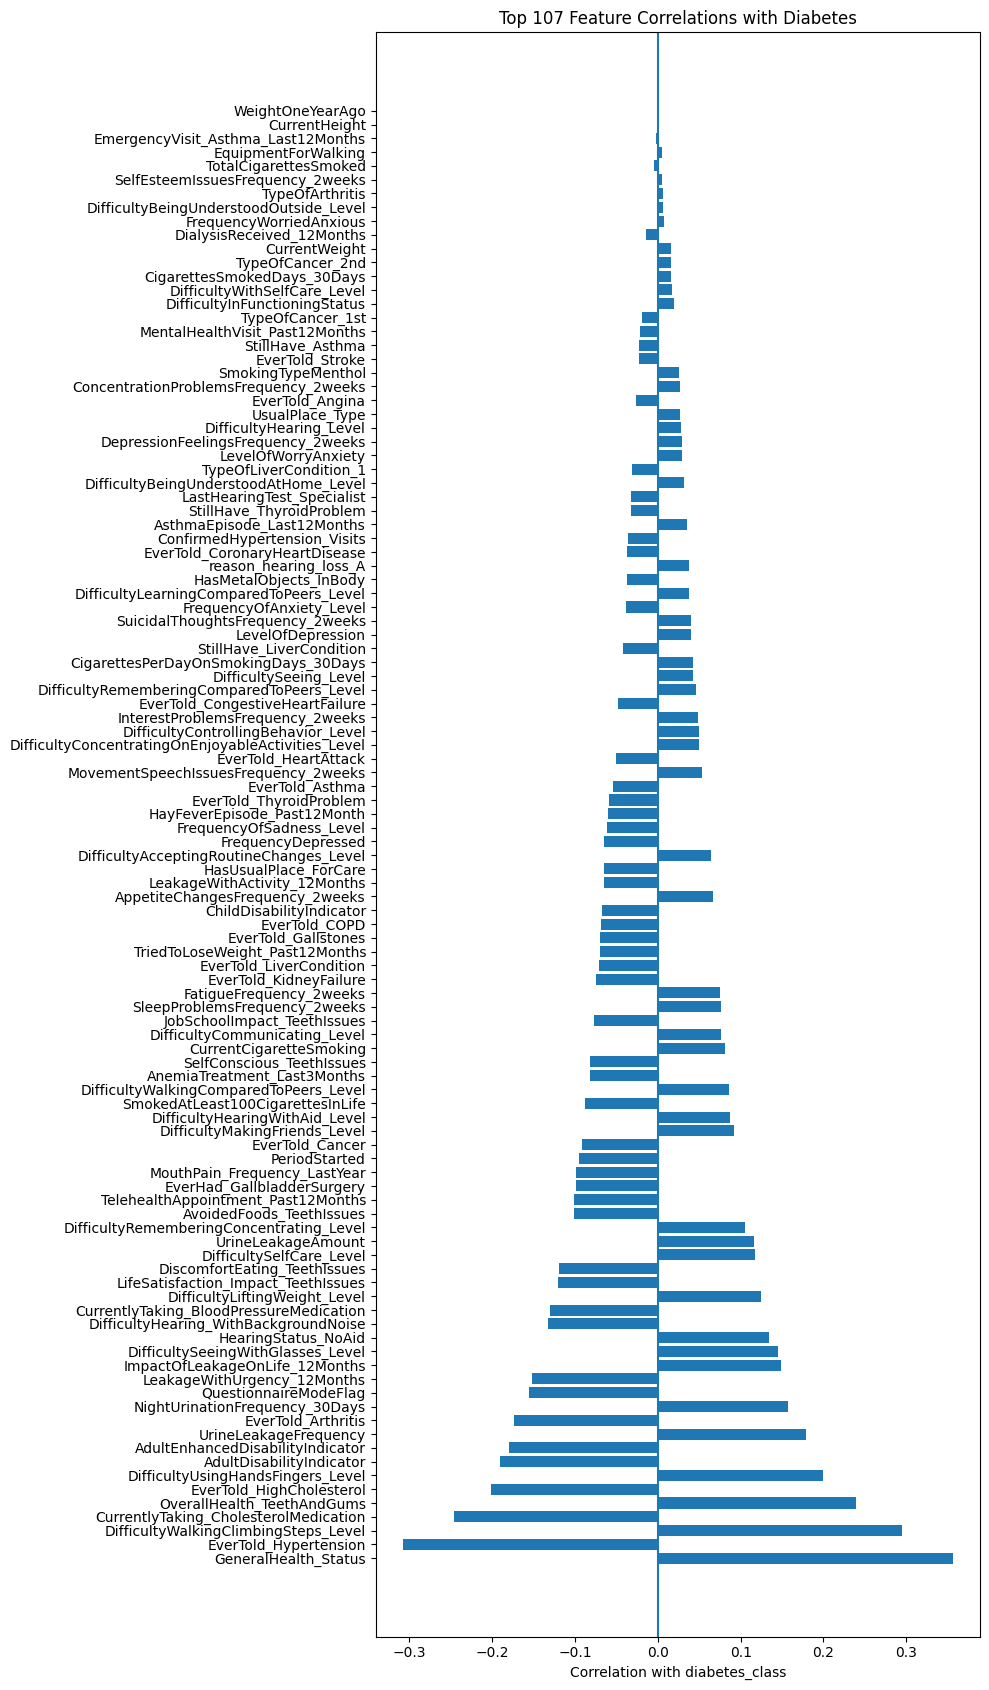

In [656]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert correlations to Series
corr_series = pd.Series(sorted_correlations)
print(f"Number of features with correlations: {corr_series.size}")
# Take top N by absolute correlation
TOP_N = 107
top_corr = corr_series.reindex(
    corr_series.abs().sort_values(ascending=False).head(TOP_N).index
)

MODEL_INPUT_FEATURES = list(top_corr.index)

# Map column names -> renamed variables
def get_label(col):
    try:
        desc_info = desc(col)
        return desc_info['renamed']
    except:
        return col

labels = [get_label(col) for col in top_corr.index]

# Plot horizontal bar chart
plt.figure(figsize=(10, 17))
plt.barh(labels, top_corr.values)
plt.axvline(0)  # zero reference
plt.xlabel('Correlation with diabetes_class')
plt.title(f'Top {TOP_N} Feature Correlations with Diabetes')
plt.tight_layout()
plt.show()


In [671]:
# ============================================================
# OPTIMIZED MODEL: SMOTE + XGBoost with Threshold Tuning
# Goal: 80-90% Diabetes Recall
# ============================================================

import pandas as pd
import numpy as np
from xgboost import XGBClassifier
from sklearn.utils.class_weight import compute_sample_weight
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, precision_score, f1_score, confusion_matrix, classification_report, accuracy_score

target_names = ['No Diabetes (0)', 'Prediabetes (1)', 'Diabetes (2)']

if 'X_train' not in dir() or 'X_test' not in dir():
    print("Setting up train/test split...")
    X = combined_with_target[MODEL_INPUT_FEATURES]
    y = combined_with_target['diabetes_class']
    
    # X_filled = X.fillna(X.median())
    
    # Train/test split (80/20 stratified)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    print(f"✓ Train set: {X_train.shape}")
    print(f"✓ Test set: {X_test.shape}\n")

print("Step 1: Applying SMOTE to balance training data...")
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(f"  Original train distribution: {np.bincount(y_train)}")
print(f"  SMOTE train distribution: {np.bincount(y_train_smote)}\n")

print("Step 2: Training XGBoost on SMOTE-balanced data...")
xgb_model_final = XGBClassifier(
    objective='multi:softprob',
    eval_metric='mlogloss',
    num_class=3,
    max_depth=7,
    learning_rate=0.1,
    n_estimators=300,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    n_jobs=-1,
    verbosity=0
)

xgb_model_final.fit(X_train_smote, y_train_smote, verbose=False)
print("✓ Model trained!\n")

y_pred_proba_final = xgb_model_final.predict_proba(X_test)
y_pred_proba_diabetes = y_pred_proba_final[:, 2]  # Probability of Diabetes (class 2)

print("Step 3: Tuning threshold for Diabetes recall target (80-90%)...")
thresholds = np.arange(0.05, 0.50, 0.05)
results = []

for threshold in thresholds:
    y_pred_tuned = np.argmax(y_pred_proba_final, axis=1)
    diabetes_mask = y_pred_proba_diabetes > threshold
    y_pred_tuned[diabetes_mask] = 2
    
    recall_d = recall_score(y_test, y_pred_tuned, labels=[2], average=None)[0]
    prec_d = precision_score(y_test, y_pred_tuned, labels=[2], average=None)[0]
    f1_d = f1_score(y_test, y_pred_tuned, labels=[2], average=None)[0]
    acc = accuracy_score(y_test, y_pred_tuned)
    
    results.append({
        'Threshold': threshold,
        'Diabetes_Recall': recall_d,
        'Diabetes_Precision': prec_d,
        'Diabetes_F1': f1_d,
        'Overall_Accuracy': acc
    })

results_df = pd.DataFrame(results)

target_recall = 0.85
results_df['recall_distance'] = np.abs(results_df['Diabetes_Recall'] - target_recall)
best_idx = results_df['recall_distance'].idxmin()
best_threshold = results_df.loc[best_idx, 'Threshold']

print("\nThreshold tuning results:")
print(results_df.to_string(index=False))
print(f"\n✓ Optimal threshold: {best_threshold:.2f}")
print(f"  Expected Diabetes Recall: {results_df.loc[best_idx, 'Diabetes_Recall']:.1%}\n")

y_pred_final = np.argmax(y_pred_proba_final, axis=1)
diabetes_mask = y_pred_proba_diabetes > best_threshold
y_pred_final[diabetes_mask] = 2

print("="*70)
print("FINAL MODEL EVALUATION (Test Set)")
print("="*70)

test_acc_final = accuracy_score(y_test, y_pred_final)
train_acc_final = accuracy_score(y_train, xgb_model_final.predict(X_train))

print(f"Training Accuracy: {train_acc_final:.4f}")
print(f"Testing Accuracy: {test_acc_final:.4f}")
print(f"Decision Threshold (Diabetes): {best_threshold:.2f}\n")

print(classification_report(
    y_test, y_pred_final,
    target_names=target_names,
    digits=3
))

cm_final = confusion_matrix(y_test, y_pred_final)
print("\nConfusion Matrix:")
print(cm_final)

diabetes_recall_final = recall_score(y_test, y_pred_final, labels=[2], average=None)[0]
print(f"\n{'='*70}")
print(f"✓✓✓ DIABETES RECALL: {diabetes_recall_final:.1%} ✓✓✓")
print(f"{'='*70}")


Step 1: Applying SMOTE to balance training data...
  Original train distribution: [7569  961  865]
  SMOTE train distribution: [7569 7569 7569]

Step 2: Training XGBoost on SMOTE-balanced data...
✓ Model trained!

Step 3: Tuning threshold for Diabetes recall target (80-90%)...

Threshold tuning results:
 Threshold  Diabetes_Recall  Diabetes_Precision  Diabetes_F1  Overall_Accuracy  recall_distance
      0.05         0.796296            0.296552     0.432161          0.757344         0.053704
      0.10         0.680556            0.344262     0.457232          0.785015         0.169444
      0.15         0.611111            0.379310     0.468085          0.796935         0.238889
      0.20         0.560185            0.398026     0.465385          0.801618         0.289815
      0.25         0.504630            0.409774     0.452282          0.805023         0.345370
      0.30         0.476852            0.438298     0.456763          0.809281         0.373148
      0.35         0.42